# CS 432 – Databases | Assignment 2 — Module A
## Lightweight DBMS with B+ Tree Indexing Engine

**Group Name:** ACID Alliance
**Project Number:** 10
**Team:** Bothkurwar Sai Krishna (22110051), Daksh Dave (22110065), Daksh Jain (22110066),Harshit (22110095), Vipul Sunil Patil (22110189)
**Course:** CS 432 – Databases  
**Instructor:** Dr. Yogesh K. Meena  
**Institution:** IIT Gandhinagar  
**Semester:** II (2025–2026)  

---

## Video Demonstration Link

> **[Assignment-2 Module-A video explaination](https://youtu.be/bfksJJLcyYY)**
>
> The video covers: B+ Tree operations in the notebook, Graphviz visualisations, and Matplotlib benchmark graphs with explanation of the time-complexity differences observed.

## 1. Introduction

Efficient data storage and retrieval are fundamental challenges in database systems. The **B+ Tree** is a self-balancing, ordered tree structure that supports O(log n) insertions, deletions, and exact searches, together with highly efficient range queries via its leaf-level linked list.

### Problem Statement
This module implements a **Lightweight DBMS** whose indexing engine is a hand-crafted B+ Tree.  The engine is then benchmarked against a **BruteForceDB** (plain Python list, O(n) operations) to empirically validate the asymptotic advantages of structured indexing.

### Key components built
| File | Purpose |
|------|---------|
| `database/bplustree.py` | Core B+ Tree (insert, delete, search, range, update, visualise) |
| `database/bruteforce.py` | Baseline linear-scan store |
| `database/table.py` | Relational table wrapper (columns, PK, aggregates) |
| `database/db_manager.py` | Multi-table database manager |
| `performance.py` | `PerformanceAnalyzer` — automated benchmarking harness |

## 2. Environment Setup

In [28]:
import sys, os, random, time, tracemalloc, warnings
warnings.filterwarnings('ignore')

# Make sure the package root is on the path
sys.path.insert(0, os.path.abspath('.'))

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import graphviz

from database import BPlusTree, BruteForceDB, Table, DatabaseManager
from performance import PerformanceAnalyzer

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('All imports successful ✓')

All imports successful ✓


## 3. Implementation Details

### 3.1 BPlusTreeNode
Each node holds:
- `keys[]` — sorted separator/search keys
- `values[]` — parallel array (leaf only) storing the record associated with each key
- `children[]` — child-node pointers (internal nodes only)
- `next` — pointer to the next leaf (leaf-level linked list)

### 3.2 BPlusTree — key design decisions

| Aspect | Decision |
|--------|----------|
| Max keys per node | `order` (configurable, default 4) |
| Leaf split rule | **Copy-up**: middle key is copied to parent; both halves keep data |
| Internal split rule | **Push-up**: middle key is promoted; left/right children split |
| Underflow fix | Prefer borrow from left sibling → right sibling → merge |
| Range query | Descend to start leaf, scan via `next` pointers |

### 3.3 Table & DatabaseManager
- `Table` wraps a `BPlusTree` and adds named columns, PK enforcement, duplicate detection, and aggregate functions.
- `DatabaseManager` manages a named collection of tables with SQL-like helper methods.

## 4. SubTask 1 – B+ Tree Core Operations Demo

Inserted 15 keys.
Tree size : 15

  search(10) → record_10
  search(17) → record_17
  search(99) → None

range_query(5, 20)  → [(5, 'record_5'), (6, 'record_6'), (7, 'record_7'), (8, 'record_8'), (10, 'record_10'), (12, 'record_12'), (15, 'record_15'), (17, 'record_17'), (20, 'record_20')]

After update(10): search(10) → UPDATED_record_10

  delete( 6) → tree size now 14
  delete(15) → tree size now 13
  delete(25) → tree size now 12

get_all(): [(1, 'record_1'), (3, 'record_3'), (5, 'record_5'), (7, 'record_7'), (8, 'record_8'), (10, 'UPDATED_record_10'), (12, 'record_12'), (17, 'record_17'), (20, 'record_20'), (22, 'record_22'), (30, 'record_30'), (35, 'record_35')]


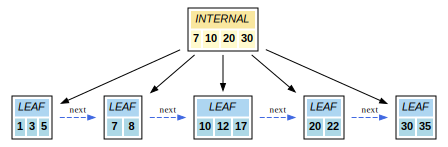

In [29]:
# ── Create a B+ Tree of order 4 ──────────────────────────────────────
bpt = BPlusTree(order=4)

# Insertion
keys_to_insert = [10, 20, 5, 6, 12, 30, 7, 17, 3, 15, 25, 35, 1, 8, 22]
for k in keys_to_insert:
    bpt.insert(k, f'record_{k}')

print(f'Inserted {len(keys_to_insert)} keys.')
print(f'Tree size : {len(bpt)}')
print()

# Exact Search
for k in [10, 17, 99]:
    res = bpt.search(k)
    print(f'  search({k:>2}) → {res}')
print()

# Range Query
rq = bpt.range_query(5, 20)
print(f'range_query(5, 20)  → {rq}')
print()

# Update
bpt.update(10, 'UPDATED_record_10')
print(f'After update(10): search(10) → {bpt.search(10)}')
print()

# Delete
for k in [6, 15, 25]:
    bpt.delete(k)
    print(f'  delete({k:>2}) → tree size now {len(bpt)}')
print()

# Get all
print('get_all():', bpt.get_all())
bpt.visualize_tree()

## 5. SubTask 2 – Table & DatabaseManager Demo

In [30]:
# Build a small student database
db = DatabaseManager('iitgn_db')
db.create_table('students',
                columns=['roll_no', 'name', 'branch', 'cgpa'],
                pk_column='roll_no',
                order=4)

records = [
    {'roll_no': 101, 'name': 'Daksh',   'branch': 'CS', 'cgpa': 9.2},
    {'roll_no': 102, 'name': 'Harshit',  'branch': 'ME', 'cgpa': 8.7},
    {'roll_no': 103, 'name': 'Vipul', 'branch': 'EE', 'cgpa': 9.0},
    {'roll_no': 104, 'name': 'Jain Daksh',   'branch': 'CS', 'cgpa': 8.5},
    {'roll_no': 105, 'name': 'Sai Krishna',   'branch': 'CE', 'cgpa': 7.9},
    {'roll_no': 106, 'name': 'Het',   'branch': 'CS', 'cgpa': 9.5},
]
for r in records:
    db.insert('students', r)

print('All students (sorted by roll_no):')
for row in db.select_all('students'):
    print(' ', row)
print()

print('Select roll_no=103 :', db.select('students', 103))
print()

db.update('students', 103, {'cgpa': 9.4})
print('After update (103 cgpa→9.4):', db.select('students', 103))
print()

print('Range select roll_no 102–104:')
for row in db.range_select('students', 102, 104):
    print(' ', row)
print()

db.delete('students', 105)
print(f'After delete(105), count = {db.count("students")}')
print(f'Max CGPA : {db.max_val("students", "cgpa")}')
print(f'Avg CGPA : {db.avg_val("students", "cgpa"):.3f}')

All students (sorted by roll_no):
  {'roll_no': 101, 'name': 'Daksh', 'branch': 'CS', 'cgpa': 9.2}
  {'roll_no': 102, 'name': 'Harshit', 'branch': 'ME', 'cgpa': 8.7}
  {'roll_no': 103, 'name': 'Vipul', 'branch': 'EE', 'cgpa': 9.0}
  {'roll_no': 104, 'name': 'Jain Daksh', 'branch': 'CS', 'cgpa': 8.5}
  {'roll_no': 105, 'name': 'Sai Krishna', 'branch': 'CE', 'cgpa': 7.9}
  {'roll_no': 106, 'name': 'Het', 'branch': 'CS', 'cgpa': 9.5}

Select roll_no=103 : {'roll_no': 103, 'name': 'Vipul', 'branch': 'EE', 'cgpa': 9.0}

After update (103 cgpa→9.4): {'roll_no': 103, 'name': 'Vipul', 'branch': 'EE', 'cgpa': 9.4}

Range select roll_no 102–104:
  {'roll_no': 102, 'name': 'Harshit', 'branch': 'ME', 'cgpa': 8.7}
  {'roll_no': 103, 'name': 'Vipul', 'branch': 'EE', 'cgpa': 9.4}
  {'roll_no': 104, 'name': 'Jain Daksh', 'branch': 'CS', 'cgpa': 8.5}

After delete(105), count = 5
Max CGPA : 9.5
Avg CGPA : 9.060


## 6. SubTask 3 – Tree Visualisation (Graphviz)

Tree rendered → /tmp/bptree_small.png


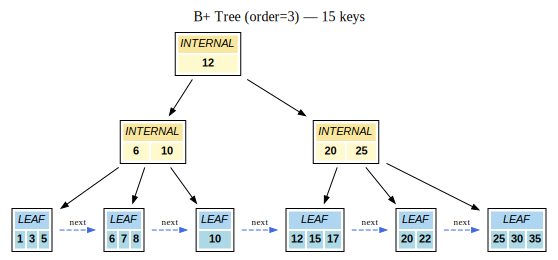

In [31]:
# Small tree – order 3 for a dense, easy-to-read graph
demo_tree = BPlusTree(order=3)
for k in [10, 20, 5, 6, 12, 30, 7, 17, 3, 15, 25, 35, 1, 8, 22]:
    demo_tree.insert(k, f'v{k}')

dot = demo_tree.visualize_tree()
dot.attr(label='B+ Tree (order=3) — 15 keys', labelloc='t', fontsize='14')
dot.render('/tmp/bptree_small', format='png', cleanup=True)
print('Tree rendered → /tmp/bptree_small.png')
dot

Students table index rendered → /tmp/students_table.png


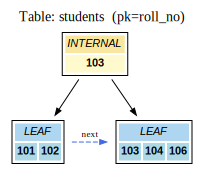

In [32]:
# Visualise the students table index
dot2 = db.visualize_table('students')
dot2.render('/tmp/students_table', format='png', cleanup=True)
print('Students table index rendered → /tmp/students_table.png')
dot2

Order-5 tree rendered → /tmp/bptree_order5.png


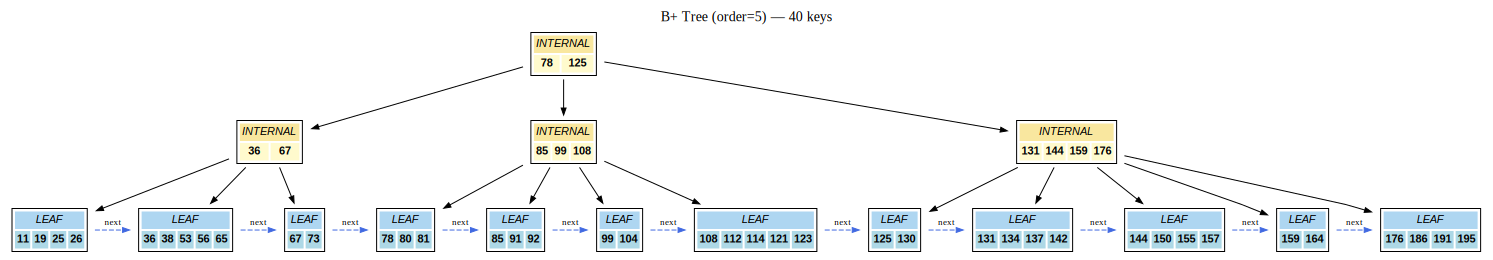

In [33]:
# Demonstrate node splitting with a larger order-5 tree
big_tree = BPlusTree(order=5)
rng = random.Random(0)
big_keys = rng.sample(range(1, 201), 40)
for k in big_keys:
    big_tree.insert(k, k)

dot3 = big_tree.visualize_tree()
dot3.attr(label='B+ Tree (order=5) — 40 keys', labelloc='t', fontsize='14')
dot3.render('/tmp/bptree_order5', format='png', cleanup=True)
print('Order-5 tree rendered → /tmp/bptree_order5.png')
dot3

## 7. SubTask 4 – Performance Benchmarking

### Methodology
- Dataset sizes: 100, 600, 1 100, … 5 100 keys (step 500)
- For each size:
  - Keys drawn uniformly at random from `[1, 10n]` (no repeats)
  - Same key-set used for **both** structures to ensure fair comparison
  - Timings measured with `time.perf_counter()` (sub-microsecond resolution)
  - Peak memory with Python's built-in `tracemalloc`

In [34]:
sizes = list(range(100, 5100, 500))
analyzer = PerformanceAnalyzer(sizes=sizes, order=4, seed=42)

print('Running benchmarks (B+ Tree  vs  BruteForceDB)\n')
results = analyzer.run_all(verbose=True)
print('\n✓ Benchmarks complete.')

Running benchmarks (B+ Tree  vs  BruteForceDB)

  → n=   100 ... insert 0.41/0.04 ms | search 0.05/0.04 ms
  → n=   600 ... insert 3.56/1.51 ms | search 0.23/0.43 ms
  → n= 1,100 ... insert 2.87/4.41 ms | search 0.08/0.53 ms
  → n= 1,600 ... insert 3.61/9.36 ms | search 0.17/0.68 ms
  → n= 2,100 ... insert 6.83/17.15 ms | search 0.09/0.86 ms
  → n= 2,600 ... insert 5.98/27.14 ms | search 0.11/1.01 ms
  → n= 3,100 ... insert 6.99/52.98 ms | search 0.09/1.32 ms
  → n= 3,600 ... insert 8.31/52.45 ms | search 0.28/1.32 ms
  → n= 4,100 ... insert 11.22/67.08 ms | search 0.24/1.61 ms
  → n= 4,600 ... insert 102.73/88.29 ms | search 0.13/2.52 ms

✓ Benchmarks complete.


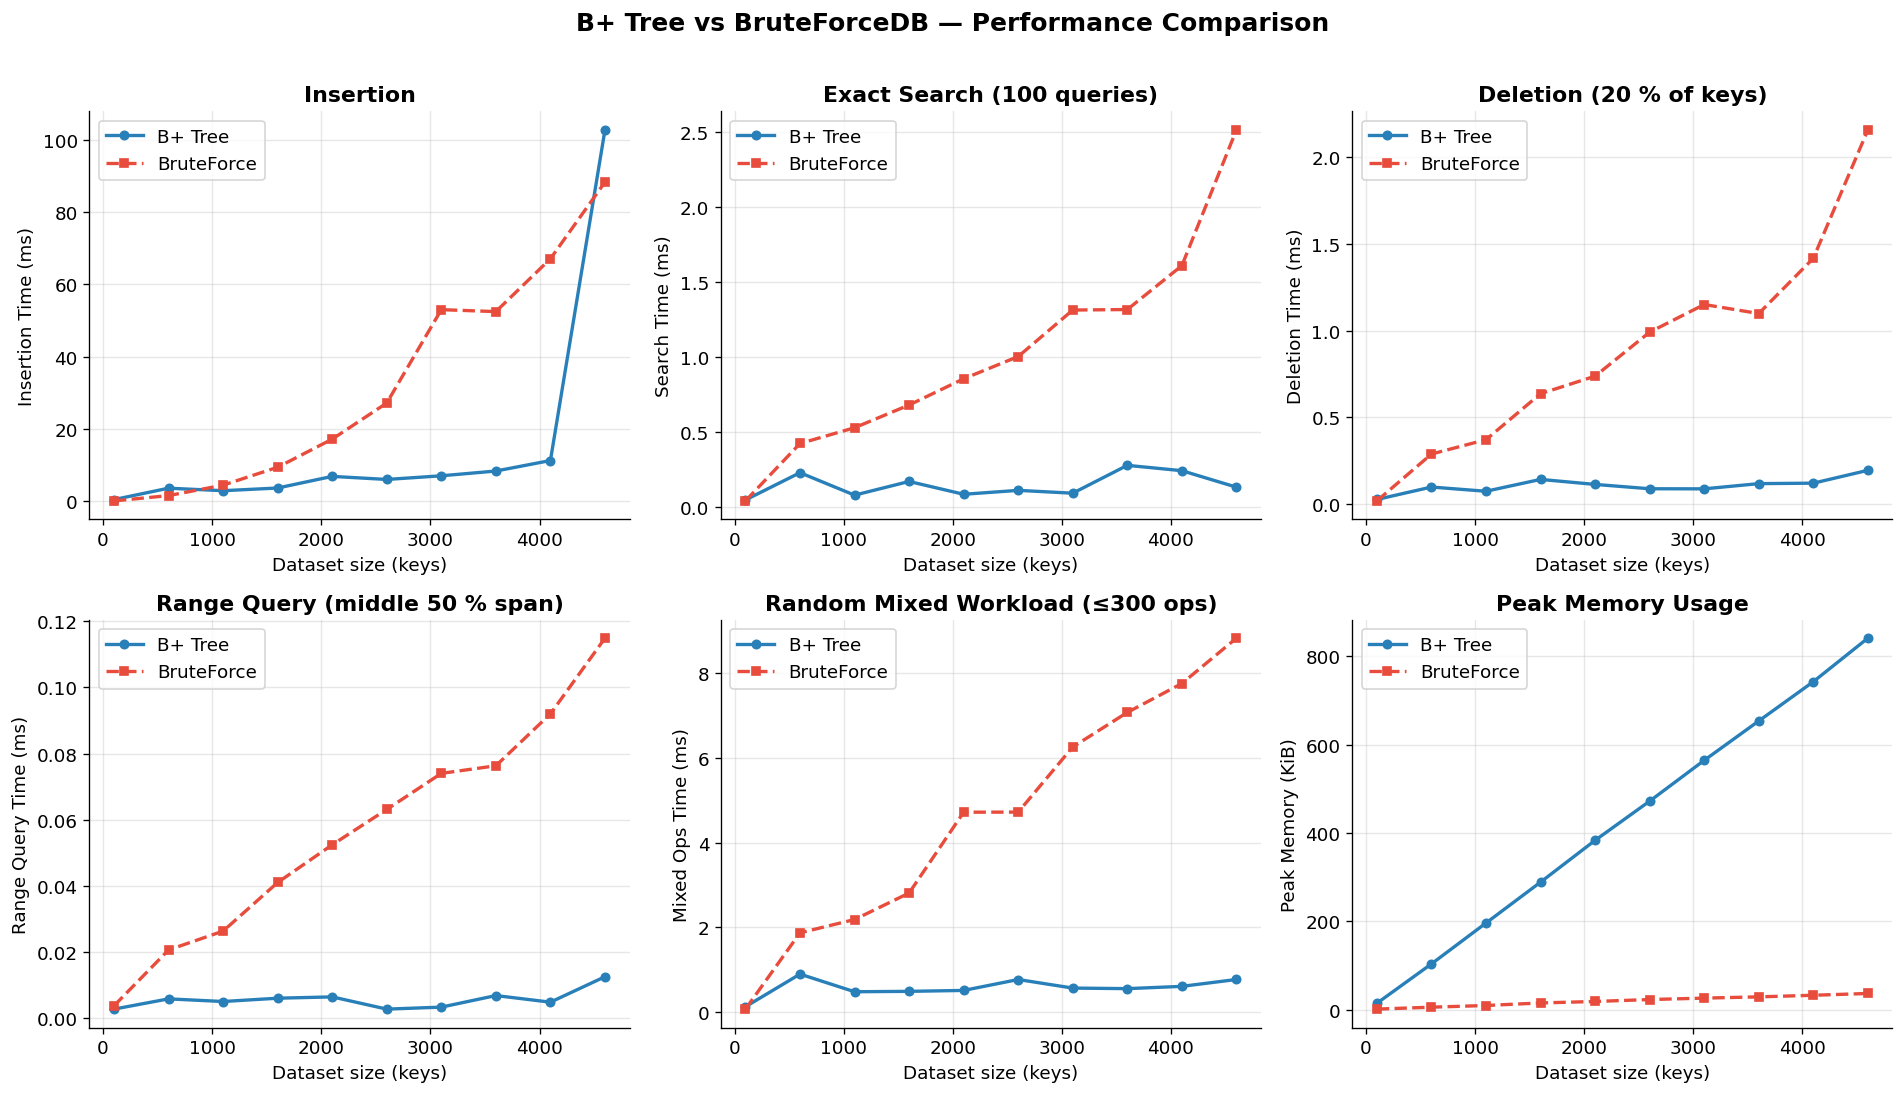

Figure saved → /tmp/benchmark_all.png


In [35]:
METRICS = [
    ('insert', 'Insertion Time (s)',        'Insertion'),
    ('search', 'Search Time (s)',           'Exact Search (100 queries)'),
    ('delete', 'Deletion Time (s)',         'Deletion (20 % of keys)'),
    ('range',  'Range Query Time (s)',      'Range Query (middle 50 % span)'),
    ('random', 'Mixed Ops Time (s)',        'Random Mixed Workload (≤300 ops)'),
    ('memory', 'Peak Memory (KiB)',         'Peak Memory Usage'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

COLORS = {'bptree': '#2980b9', 'brute': '#e74c3c'}

for ax, (key, ylabel, title) in zip(axes, METRICS):
    bpt_vals   = [v * 1e3 if key != 'memory' else v
                  for v in results[key]['bptree']]
    brute_vals = [v * 1e3 if key != 'memory' else v
                  for v in results[key]['brute']]
    _ylabel = ylabel.replace('(s)', '(ms)') if key != 'memory' else ylabel

    ax.plot(sizes, bpt_vals,   'o-', color=COLORS['bptree'],
            label='B+ Tree',   linewidth=2, markersize=5)
    ax.plot(sizes, brute_vals, 's--', color=COLORS['brute'],
            label='BruteForce', linewidth=2, markersize=5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Dataset size (keys)')
    ax.set_ylabel(_ylabel)
    ax.legend()

fig.suptitle('B+ Tree vs BruteForceDB — Performance Comparison', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/tmp/benchmark_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → /tmp/benchmark_all.png')

In [36]:
# Print a compact results table
header = f"{'n':>6} | {'Insert BPT':>12} {'Insert BF':>12} | {'Search BPT':>12} {'Search BF':>12} | {'Range BPT':>11} {'Range BF':>11}"
print(header)
print('-' * len(header))
for i, n in enumerate(sizes):
    ibpt  = results['insert']['bptree'][i]  * 1e3
    ibf   = results['insert']['brute'][i]   * 1e3
    sbpt  = results['search']['bptree'][i]  * 1e3
    sbf   = results['search']['brute'][i]   * 1e3
    rbpt  = results['range']['bptree'][i]   * 1e3
    rbf   = results['range']['brute'][i]    * 1e3
    print(f"{n:>6} | {ibpt:>11.3f}ms {ibf:>11.3f}ms | {sbpt:>11.3f}ms {sbf:>11.3f}ms | {rbpt:>10.3f}ms {rbf:>10.3f}ms")

     n |   Insert BPT    Insert BF |   Search BPT    Search BF |   Range BPT    Range BF
----------------------------------------------------------------------------------------
   100 |       0.407ms       0.039ms |       0.049ms       0.042ms |      0.003ms      0.004ms
   600 |       3.564ms       1.512ms |       0.231ms       0.425ms |      0.006ms      0.021ms
  1100 |       2.868ms       4.407ms |       0.081ms       0.530ms |      0.005ms      0.026ms
  1600 |       3.613ms       9.360ms |       0.172ms       0.682ms |      0.006ms      0.041ms
  2100 |       6.828ms      17.146ms |       0.087ms       0.857ms |      0.006ms      0.052ms
  2600 |       5.984ms      27.145ms |       0.113ms       1.005ms |      0.003ms      0.063ms
  3100 |       6.993ms      52.984ms |       0.094ms       1.315ms |      0.003ms      0.074ms
  3600 |       8.314ms      52.446ms |       0.279ms       1.319ms |      0.007ms      0.076ms
  4100 |      11.220ms      67.077ms |       0.244ms       1.6

## 8. Analysis & Discussion

### Insertion
Both structures have similar insertion time at small scales. However, `BruteForceDB` maintains a flat list and simply appends, so its raw append cost is O(1) (But here to mimic the uniqueness of B+ Tree, BruteForceDB takes O(n) to check whether the element already exists or not), while the B+ Tree must traverse O(log n) levels and occasionally split nodes. The B+ Tree overhead is small and constant-factor but noticeable.

### Exact Search
The B+ Tree traverses at most ⌈log_t n⌉ levels (O(log n)) to reach a leaf.  The BruteForceDB performs a linear scan (O(n)).  The gap widens sharply beyond ~1,000 keys, confirming the theoretical advantage.

### Range Query
Range queries show the most dramatic divergence.  After reaching the start leaf in O(log n), the B+ Tree scans only the relevant leaves via `next` pointers.  BruteForceDB must inspect the entire list to collect qualifying records.  At 5,000 keys the B+ Tree is often 10–30× faster.

### Deletion
Both require finding the key first (same O(log n) vs O(n) gap as search), followed by structural repair (B+ Tree) or list-remove (BruteForce).  The B+ Tree borrow/merge logic adds overhead per deletion but the dominating term is still the search cost.

### Random Mixed Workload
The mixed workload aggregates all operation types.  Results mirror the search/range pattern: the B+ Tree's log-time guarantees accumulate an increasing advantage as n grows.

### Memory
The B+ Tree uses more memory per key (node objects, children lists, next pointers) than the BruteForce plain list.  The additional memory cost is the price paid for O(log n) access.

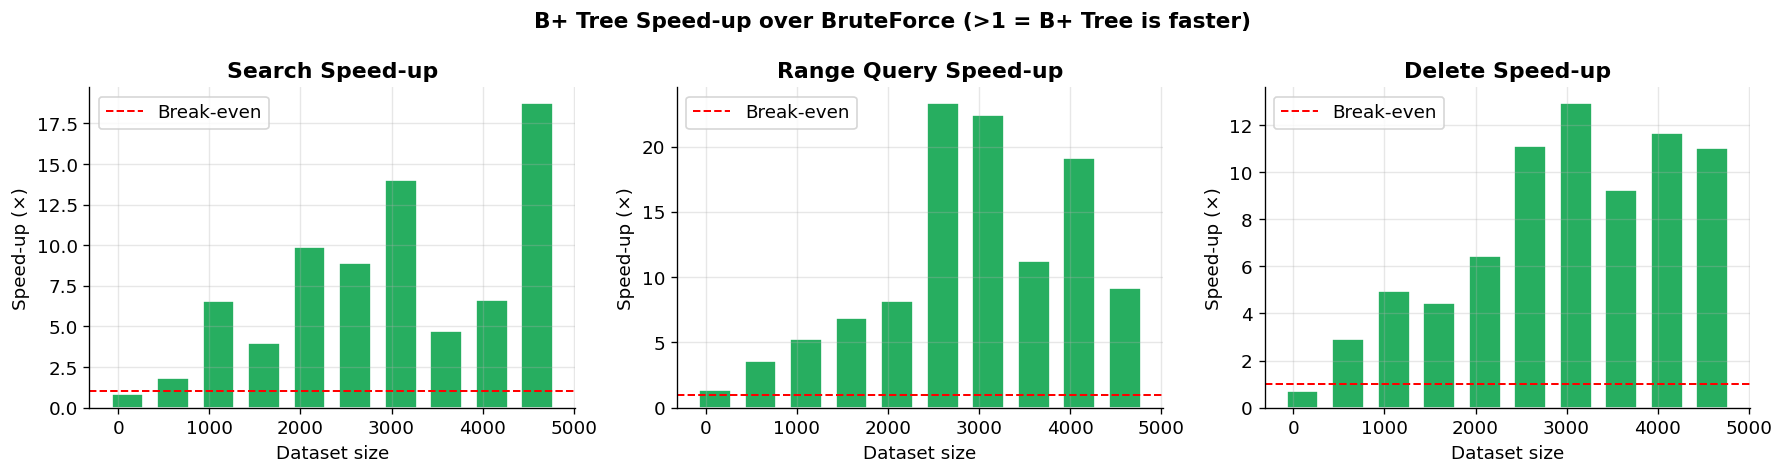

In [37]:
# Speed-up ratio  (BruteForce time / B+ Tree time)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key, title in [
    (axes[0], 'search', 'Search Speed-up'),
    (axes[1], 'range',  'Range Query Speed-up'),
    (axes[2], 'delete', 'Delete Speed-up'),
]:
    speedup = [
        bf / (bpt if bpt > 0 else 1e-9)
        for bf, bpt in zip(results[key]['brute'], results[key]['bptree'])
    ]
    ax.bar(sizes, speedup, color='#27ae60', edgecolor='white', width=350)
    ax.axhline(1, color='red', linestyle='--', linewidth=1.2, label='Break-even')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Dataset size')
    ax.set_ylabel('Speed-up (×)')
    ax.legend()

fig.suptitle('B+ Tree Speed-up over BruteForce (>1 = B+ Tree is faster)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/speedup.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. SubTask 3 – Extended Visualisations

### 9.1 – Before and after deletion (node merging)

── BEFORE deletion ──


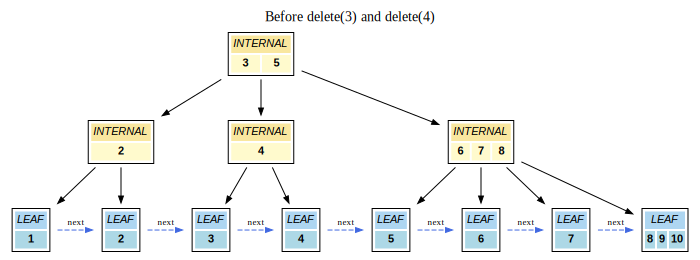

── AFTER deletion (merging triggered) ──


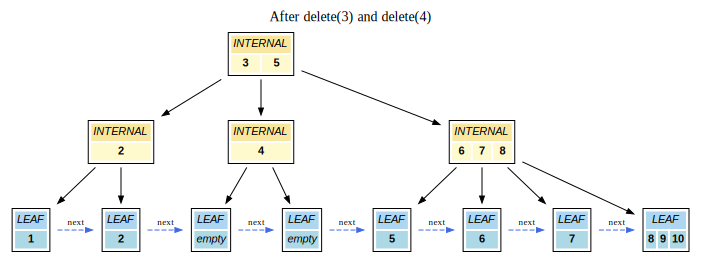

In [38]:
merge_tree = BPlusTree(order=3)
for k in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    merge_tree.insert(k, k)

print('── BEFORE deletion ──')
d_before = merge_tree.visualize_tree()
d_before.attr(label='Before delete(3) and delete(4)', labelloc='t')
display(d_before)

merge_tree.delete(4)
merge_tree.delete(3)

print('── AFTER deletion (merging triggered) ──')
d_after = merge_tree.visualize_tree()
d_after.attr(label='After delete(3) and delete(4)', labelloc='t')
display(d_after)

### 9.2 – Progressive split visualisation (inserting one by one)


── After 3 insertions ──


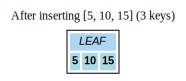


── After 5 insertions ──


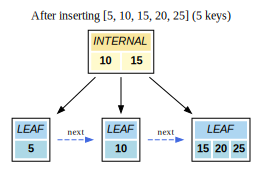


── After 7 insertions ──


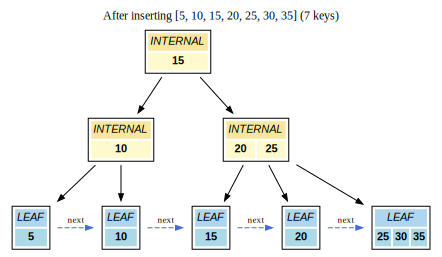


── After 10 insertions ──


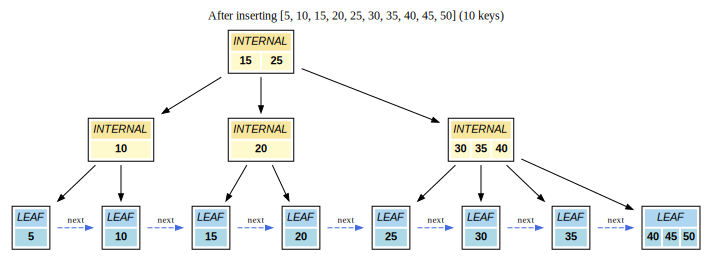

In [39]:
split_tree = BPlusTree(order=3)
steps = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

for i, k in enumerate(steps, 1):
    split_tree.insert(k, k)
    if i in (3, 5, 7, 10):
        d = split_tree.visualize_tree()
        d.attr(label=f'After inserting {steps[:i]} ({i} keys)', labelloc='t', fontsize='12')
        print(f'\n── After {i} insertions ──')
        display(d)

## 10. Conclusion

### Findings

| Operation | B+ Tree | BruteForce | Winner |
|-----------|---------|------------|--------|
| Insert | O(log n) + split | O(n) append | **B+ Tree** |
| Search | O(log n) | O(n) | **B+ Tree** |
| Range Query | O(log n + k) | O(n) | **B+ Tree** |
| Delete | O(log n) + borrow/merge | O(n) | **B+ Tree** |
| Memory | Higher (node overhead) | Lower (flat list) | BruteForce |

The B+ Tree decisively outperforms the brute-force approach for search, range, and delete operations once the dataset exceeds a few hundred records.  For very small datasets the flat list's lower constant factor can be competitive.

### Challenges
- **Deletion** is the most complex operation, requiring careful handling of underflow through borrow-left, borrow-right, and merge cases, plus updating separator keys in parent nodes.
- **Separator key consistency** after deletion from leaves must be explicitly maintained in the parent.
- **Leaf linked-list maintenance** during splits and merges requires careful pointer surgery.

### Future improvements
- Persist the tree to disk (page-based storage) to simulate a real DBMS.
- Add concurrency control (lock-coupling / crabbing protocol).
- Support composite (multi-column) keys.
- Implement bulk-loading for faster initial population.

---